# M3A3 - Transfer learning e Refinamento com Redes Pré-treinadas 

Na prática de hoje vamos refinar modelos de aprendizado profundo com [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision

Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

In [3]:
# Definir o pré-processamento dos dados.
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
                                            torchvision.transforms.Resize(256),
                                            torchvision.transforms.CenterCrop(224)])

# Carregar o conjunto de treino.
train_data = torchvision.datasets.MNIST(
    root='./data',      # Pasta para salvar os dados.
    train=True,         # Busca pelo sub conjunto de treino.
    download=True,      # Download do dados se necessário.
    transform=transform # Transformação a ser aplicada.
)

# Carregar o conjunto de teste.
test_data = torchvision.datasets.MNIST(
    root='./data',      # Pasta para salvar os dados.
    train=False,        # Busca pelo sub conjunto de teste.
    download=True,      # Download do dados se necessário.
    transform=transform # Transformação a ser aplicada.
)

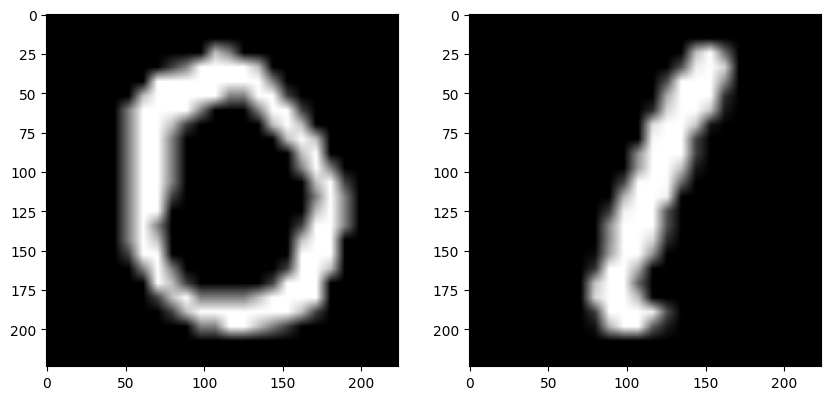

In [9]:
# Visualizar duas imagens aleatórias da base de dados.
indexes = [np.random.randint(0, len(train_data)), np.random.randint(0, len(train_data))]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(train_data[indexes[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1].imshow(train_data[indexes[1]][0].numpy().transpose(1,2,0), cmap="gray")
plt.show()

## Refinar Modelo

Agora vamos carregar o modelo e refinar.

In [10]:
# Carregar o modelo
vgg_16_model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)

# Vamos alterar a última camada.
num_classes = 10  # Número de classes na nova base.
in_features = vgg_16_model.classifier[6].in_features # Features que chegam na última camada.
vgg_16_model.classifier[6] = torch.nn.Linear(in_features, num_classes) # Substiu a última camada.

# Vamos alterar a primeira camada da rede.
new_first_conv = torch.nn.Conv2d(1, 64, kernel_size=3, padding=1)
# Replace the original first layer
vgg_16_model.features[0] = new_first_conv

In [11]:

# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()

# Criar o dataloader para iterar nos dados.
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

# Validar dispositivo de treino.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Colocar modelo no dispositivo.
vgg_16_model.to(device)

# Vamos medir a performance do modelo sem o refinamento.
correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    # Coloando os dados nos dispositivos.
    data = data.to(device)
    target = target.to(device)

    # Processando os dados.
    output = vgg_16_model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct = correct + 1

# Calcula acurácia.
acc = correct/len(test_data)
print(f"Acurácia com modelo sem refinamento: {acc * 100}%")

Acurácia com modelo sem refinamento: 8.19%


In [12]:
########################
## Processo de treino. ##
########################

# Criando otimizador.
optimizer = torch.optim.SGD(vgg_16_model.parameters(), lr=0.0001)

# Definindo função de perda.
loss_criterion = torch.nn.CrossEntropyLoss()

# Criar o dataloader de treino.
batch_size = 16 # Define quantas instâncias serão processadas em uma passada do modelo.
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)

# Laço de treinamento.
epochs = 1
for epoch in range(epochs):
    # Colocar modelo em modo de treino.
    vgg_16_model.train()

    # Colocar modelo no dispositivo.
    vgg_16_model.to(device)
    
    # Função de perda e Acurácia para epóca.
    train_loss = 0.0
    train_acc = 0.0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Move os dados para o dispositivo de computação.
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Limpando os gradientes do otimizador.
        optimizer.zero_grad()

        # Passando informação no modelo.
        outputs = vgg_16_model(inputs)
        
        # Calculando a função de perda.
        loss = loss_criterion(outputs, labels)

        # Backpropagation dos gradientes.
        loss.backward()

        # Atualização dos parâmetros.
        optimizer.step()

        # Compute the total loss for the batch and add it to train_loss
        train_loss += loss.item() * inputs.size(0)
        
        # Calcule a acurácia.
        _, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))
        
        # Calcular a acurácia do batch.
        acc = torch.mean(correct_counts.type(torch.FloatTensor))
        
        # Calcular a acurácia total.
        train_acc += acc.item() * inputs.size(0)
        print("Batch number: {:03d}/{:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}".format(batch_idx, len(train_data) // batch_size, loss.item(), acc.item()))


Batch number: 000/3750, Training: Loss: 2.3683, Accuracy: 0.0625
Batch number: 001/3750, Training: Loss: 2.4069, Accuracy: 0.0625
Batch number: 002/3750, Training: Loss: 2.2526, Accuracy: 0.1250
Batch number: 003/3750, Training: Loss: 2.4060, Accuracy: 0.0000
Batch number: 004/3750, Training: Loss: 2.3372, Accuracy: 0.1875
Batch number: 005/3750, Training: Loss: 2.2368, Accuracy: 0.1875
Batch number: 006/3750, Training: Loss: 2.2772, Accuracy: 0.2500
Batch number: 007/3750, Training: Loss: 2.2069, Accuracy: 0.1250
Batch number: 008/3750, Training: Loss: 2.3905, Accuracy: 0.0625
Batch number: 009/3750, Training: Loss: 2.2729, Accuracy: 0.2500
Batch number: 010/3750, Training: Loss: 2.3123, Accuracy: 0.1250
Batch number: 011/3750, Training: Loss: 2.3533, Accuracy: 0.0625
Batch number: 012/3750, Training: Loss: 2.3296, Accuracy: 0.0625
Batch number: 013/3750, Training: Loss: 2.4343, Accuracy: 0.0625
Batch number: 014/3750, Training: Loss: 2.3461, Accuracy: 0.0625
Batch number: 015/3750, T

In [ ]:
# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()

# Criar o dataloader para iterar nos dados.
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=False, num_workers=1)

# Vamos medir a performance do modelo sem o refinamento.
correct = 0
for batch_idx, (data, target) in enumerate(test_loader):
    # Coloando os dados nos dispositivos.
    data = data.to(device)
    target = target.to(device)

    # Processando os dados.
    output = vgg_16_model(data)
    if target == torch.argmax(torch.softmax(output, dim=1)):
        correct = correct + 1

# Calcula acurácia.
acc = correct/len(test_data)
print(f"Acurácia com modelo com refinamento: {acc * 100}%")

Acurácia com modelo com refinamento: 95.61%


: 

E com isso terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas vamos trasbalhar com problemas clássicos de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://docs.pytorch.org/vision/0.8/datasets.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Altere os hiperparâmetros, como número de epocas, tamanho do batch e learning rate do otimizador.
- [ ] Tente utilizar outro modelo pré-treinado da mesma forma que utilizamos o modelo VGG 16.